# 线性规划实际应用

## 大规模工业生产建模案例



### 物料清单树

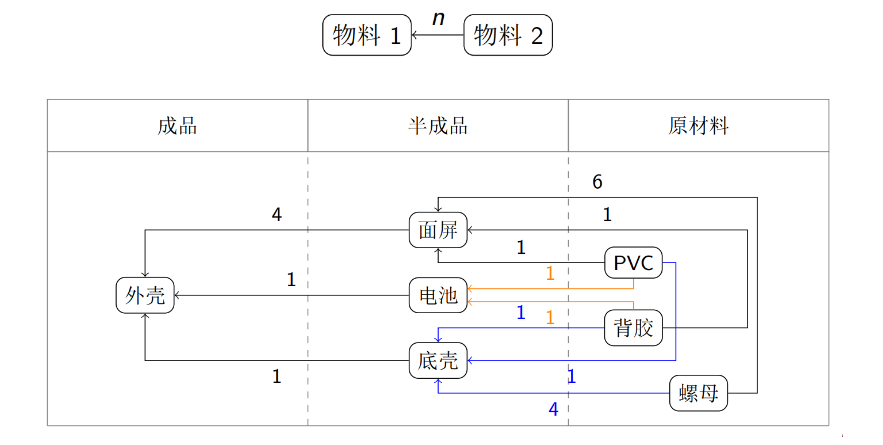

生产一个外壳需要多少螺母？使用矩阵记录物料消耗关系



成品-半成品矩阵
$$
A = 
\begin{bmatrix}
4 & 1 & 1 \\
\end{bmatrix}
$$

半成品原材料矩阵
$$
B = 
\begin{bmatrix}
1 & 1 & 6 \\
1 & 1 & 0 \\
1 & 1 & 4
\end{bmatrix}
$$


矩阵 $A \times B$ 表示成品需要原材料的数量

$$
A \times B= 

\begin{bmatrix}
6 & 6 & 28 \\
\end{bmatrix}
$$

### 问题描述

给定企业产能限量、单位产能消耗、产品单位利润，以及物料库存和物料清单树，如何安排生产计划实现利润最大化？

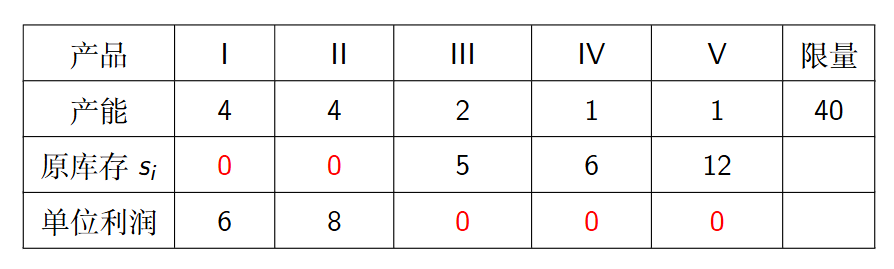

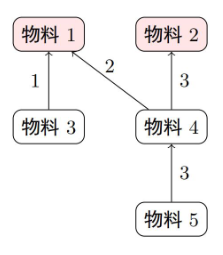

新库存=原库存+生产量-消耗量

- $s_i$：产品 $i$ 的原库存
- $x_i$：产品 $i$ 的生产量
- $u_{ij}$：生产一个产品 $i$ 需要消耗的产品 $j$ 的数量
- $y_i$：产品 $i$ 生产后的新库存

公式：

$$
y_i = s_i + x_i - \sum_{j \in I} u_{ji} x_j
$$

排产模型扩展：

$$
\begin{aligned}
\max \quad & \sum\limits_{i\in I} r_i y_i\\
\text{s.t.} \quad & y_i = s_i + x_i - \sum_{j \in I} u_{ji} x_j, \quad & \forall i \in I\\
\quad & \sum\limits_{i \in I} p_i x_i \leq P_j \quad & \forall j \in J \\
\quad & x_i \geq 0, y_i \geq 0, \quad& \forall i\in I
\end{aligned}

$$

## 动态排产问题

六国化工是一家集团型磷复肥化工企业，是国家重点发展的大型磷复肥生产骨干企业。公司主要从事化肥、肥料、化学制品、化学原料的生产、加工与销售。对以下几种产品进行生产计划，产能约束如下表所示。

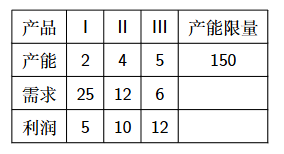


面对带时间窗的动态需求，企业该如何动态安排生产计划，以求最大化利润？

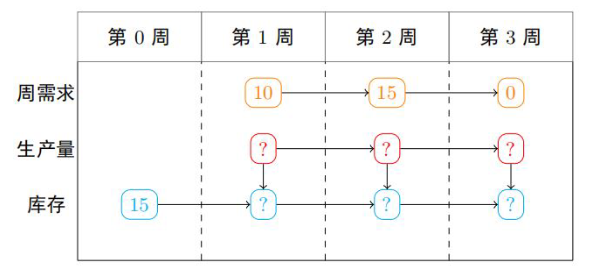


期初+周内生产-期末需求=下周期初

下周期初>=0

定义：

- $x_{ij}$：第 $j$ 周生产的第 $i$ 个产品的数量
- 更新目标函数：最大化各个周加总的产量所转换成的利润
- 更新产能约束：限制每周的总产能
- 更新周需求量
- 引入生产时间与初始库存

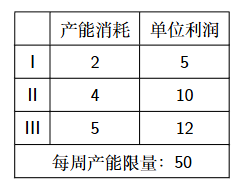

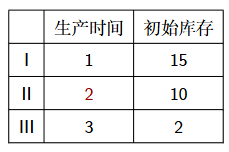

周需求量：

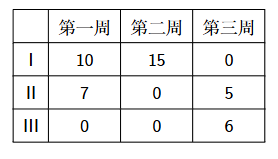

### 更新目标函数

最大化利润： 
$$
\max \quad \sum_{j \in J} 5x_{1j} + 10x_{2j} + 12x_{3j}
$$

每周产能约束：

$$
\text{s.t.} \quad 2x_{1j} + 4x_{2j} + 5x_{3j} \leq 50,  \quad \forall j \in J
$$

定义：
- $x_{ij}$：第 $j$ 周生产的第 $i$ 个产品的生产量
- $y_{ij}$ 表示产品 $i$ 在第 $j$ 周的库存量，更新库存约束
- $t_{i}$：产品 $i$ 的生产周期
- $d_{ij}$：第 $j$ 周产品 $i$ 的需求量

$$
\begin{aligned}
y_{ij} = y_{i,j-1} + x_{i,j-t_i} - d_{ij} \quad \forall i \in I, j \in J \\ 
y_{ij} \geq 0 \quad \forall i \in I, j \in J
\end{aligned}
$$

因此，完整的动态排产模型如下：

$$
\begin{aligned}
\max \quad & \sum_{i \in I}\sum_{j \in J} r_i x_{ij} \\
\text{s.t.} \quad & \sum_{i \in I} p_i x_{ij} \leq P_j,  \quad \forall j \in J \\
\quad &y_{ij} = y_{i,j-1} + x_{i,j-t_i+1} - d_{ij} \quad \forall i \in I, j \in J \\ 
\quad & x_{ij}, y_{ij} \geq 0 \quad \forall i \in I, j \in J
\end{aligned}
$$

#### COPT实现

实际求解的时候，由于本来就有库存，因此需要定义一个第0周，表示期初库存。对于第0周，生产量为0。

In [9]:
from coptpy import *

class instance:
    def __init__(self):
        self.r = [5, 10, 12]
        self.p = [2, 4, 5]
        self.P = [0, 50, 50, 50]
        self.d = [[0, 0, 0], [10, 15, 0], [7, 0, 5], [0, 0, 6]]
        self.t = [1, 2, 3]
        self.y0 = [15, 10, 2]

In [ ]:
def build_and_run_1(instance=None):
    env = Envr()
    model = env.createModel("production model1")

    I = len(instance.r)       # 产品种类数
    J = len(instance.P) + 1   # 时间段数（包括初始库存）
    X, Y = {}, {}

    for i in range(I):
        for j in range(J):
            X[i, j] = model.addVar(name="x_{}_{}".format(i, j), vtype=COPT.CONTINUOUS, lb=0)
            Y[i, j] = model.addVar(name="y_{}_{}".format(i, j), vtype=COPT.CONTINUOUS, lb=0)

    obj = LinExpr()
    for i in range(I):
        for j in range(J):
            obj.addTerms(X[i, j], instance.r[i])

    model.setObjective(obj, COPT.MAXIMIZE)

    for j in range(J):
        constr = LinExpr()
        for i in range(I):
            constr.addTerms(X[i, j], instance.p[i])
        model.addConstr(constr <= instance.P[j], name="capacity_{}".format(j))
    
    for i in range(I):
        model.addConstr(Y[i, 0] == instance.y0[i], name="initial_inventory_{}".format(i))
    
    for i in range(I):
        for j in range(1, J):
            constr = LinExpr()
            constr.addTerms(Y[i, j - 1], 1)
            if j - instance.t[i] >= 0:
                constr.addTerms(X[i, j - instance.t[i]] + 1, 1)
            constr.addTerms(Y[i, j], -1)
            constr.addTerms(instance.d[i][j], -1)
            model.addConstr(constr == 0, name="inventory_balance_{}_{}".format(i, j))

    model.solve()

    if model.status == COPT.OPTIMAL:
        print("Optimal objective value: ", model.objVal)
        for i in range(I):
            for j in range(J):
                print("x_{}_{}: {}".format(i, j, X[i, j].x))
                print("y_{}_{}: {}".format(i, j, Y[i, j].x))

In [11]:
instance = instance()
build_and_run_1(instance)

Cardinal Optimizer v7.2.11. Build date Aug  1 2025
Copyright Cardinal Operations 2025. All Rights Reserved



IndexError: list index out of range

### 延迟交付问题

若在产能约束的条件下，无法得到满足约束的解，如何解决排产问题？

- 目标函数：转为最小化成本问题（延迟交付存在成本）
- 允许产品延迟交付


引入：

- $z_{ij}$ 表示第 $j$ 周产品 $i$ 的实际交付量
- $\delta_{ij}$ 表示第 $j$ 周产品 $i$ 的延迟交付量
- $c_{ij}$ 表示第 $j$ 周产品 $i$ 的单位延迟交付成本

更新目标函数：

最小化成本：

$$
\min \quad \sum_{i \in I, j \in J} c_{ij} \delta_{ij}
$$

库存约束：

$$
\begin{aligned}
\quad y_{ij} = y_{i,j-1} + x_{i,j-t_i} - z_{ij} \quad \forall i \in I, j \in J \\
\delta_{ij} = d_{ij} - z_{ij} \quad \forall i \in I, j \in J \\
\delta_{ij} \geq 0 \quad \forall i \in I, j \in J
\end{aligned}

$$

因此，模型更新为：

$$
\begin{aligned}
\min \quad & \sum_{i \in I, j \in J} c_{ij} \delta_{ij} \\
\quad & \sum_{i \in I} p_i x_{ij} \leq P_j,  \quad &\forall j \in J \\
\quad & y_{ij} = y_{i,j-1} + x_{i,j-t_i} - z_{ij} \quad &\forall i \in I, j \in J \\
\quad &\delta_{ij} = d_{ij} - z_{ij} \quad & \forall i \in I, j \in J \\
\quad & x_{ij}, y_{ij}, z_{ij}, \delta_{ij} \geq 0 \quad & \forall i \in I, j \in J
\end{aligned}

$$

## COPT求解实际案例

## 问题描述

某公司生产一种可折叠的桌子，生产每件产品的原成本价为90元，人工工时为5个小时。产品单价为300美元。该公司在一月初有1000名工人，持有库存15000件。每位工人每小时正常薪资为30元，每个工人每天正常工作8小时，多出来的视作加班时间，时薪为40元。每个月的工作天数按照20天计算。假设公司的的生产机器足够，工时不受到工作机器限制。每个工人每个月加班时长不多于20小时。持有库存会产生库存成本。如果产能不足会产生缺货成本。公司可以选择外包来弥补缺货部分。没见产品的外包成本是200元，缺货成本是35元。每件产品每月的库存成本是15元。公司的所有员工都是临时工，可以灵活决定每月的雇佣以及解雇人数。雇佣和解雇单个员工的成本是5000元和8000元。公司已经预测了1~6月的需求量：[20000, 40000, 42000, 35000, 19000, 18500]。请为公司制定生产计划、工人工作计划以及雇佣与解雇员工计划，使得公司6个月的总净收益最大，同时6月月底至少持有10000件库存。

In [ ]:
from coptpy import *

class Instance():
    def __init__(self):
        self.period_num = 7                      # 周期数
        self.raw_material_cost = 90              # 原材料成本
        self.unit_product_time = 5               # 单位产品需要的工时
        self.price = 300                         # 产品售价
        self.init_employee_num = 1000            # 1月初剩余的员工个数
        self.init_inventory = 15000              # 1月初的员工数量
        self.normal_unit_salary = 30             # 正常单位工时工资
        self.overtime_unit_salary = 40           # 加班单位工时工资
        self.work_day_num = 20                   # 每月工作的天数
        self.work_time_each_day = 8              # 员工每天的正常工作时间
        self.outsource_unit_cost = 200           # 外包单位成本
        self.overtime_upper_limit = 20           # 每个工人每月的加班工时上限
        self.unit_inventory_cost = 15            # 单位库存成本
        self.unit_shortage_cost = 35             # 单位缺货成本
        self.hire_cost = 5000                    # 单个工人的雇佣成本
        self.fire_cost = 8000                    # 单个工人的解雇成本
        self.inventory_LB_of_last_month = 10000   # 6月底的最低库存要求

        # 预测需求量（12月的用0补充）
        self.demand = [0, 20000, 40000, 42000, 35000, 19000, 18500]


In [ ]:
def build_production_plan_model_and_solve(instance=None):
    env = Envr()
    model = env.createModel("production model")

    x, y, I, e, H, F, L, P, S, O, z = {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}
    for i in range(instance.period_num):
        x[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='x_'+str(i))
        y[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='y_'+str(i))
        I[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='I_'+str(i))
        e[i] = model.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='e_'+str(i))
        H[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='H_'+str(i))
        F[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='F_'+str(i))
        L[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='L_'+str(i))
        P[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='P_'+str(i))
        S[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.INTEGER, name='S_'+str(i))
        O[i] = model.addVar(lb=0, ub=COPT.INFINITY, vtype=COPT.CONTINUOUS, name='O_'+str(i))
        z[i] = model.addVar(lb=0, ub=1, vtype=COPT.BINARY, name='z_'+str(i))

    obj = LinExpr()

    for i in range(instance.period_num):
        obj.addTerms(S[i], instance.price)
        obj.addTerms(x[i], -instance.raw_material_cost)
        obj.addTerms(y[i], -instance.outsource_unit_cost)
        obj.addTerms(O[i], -instance.overtime_unit_salary)
        obj.addTerms(P[i], -instance.normal_unit_salary * instance.work_time_each_day * instance.work_day_num)
        obj.addConstant(-instance.init_inventory * instance.unit_inventory_cost)
        obj.addTerms(I[i], -instance.unit_inventory_cost)
        obj.addTerms(L[i], -instance.unit_shortage_cost)
        obj.addTerms(H[i], -instance.hire_cost)
        obj.addTerms(F[i], -instance.fire_cost)
    
    big_M = 100000000
    model.addConstr(I[0] == instance.init_inventory)
    model.addConstr(P[0] == instance.init_employee_num)
    model.addConstr(L[instance.period_num-1] >= instance.inventory_LB_of_last_month)
    model.addConstr(H[0] == 0)
    model.addConstr(F[0] == 0)
    model.addConstr(e[0] == 0)
    model.addConstr(x[0] == 0)
    model.addConstr(y[0] == 0)
    model.addConstr(z[0] == 0)
    model.addConstr(O[0] == 0)

    for i in range(1, instance.period_num):
        model.addConstr(I[i-1] + x[i] + y[i] + e[i] == instance.demand[i], name="instance.demand_" + str(i))
        model.addConstr(I[i-1] + x[i] + y[i] -S[i] == I[i], name="inventory_"+str(i))
        model.addConstr(e[i] - big_M * z[i] <= 0, name="stortage1_"+str(i))
        model.addConstr(1 - e[i] - big_M * (1 - z[i]) <= 0, name="stortage2_"+str(i))
        model.addConstr(L[i] - e[i] - big_M * (1-z[i]) <= 0, name="stortage3_"+str(i))
        model.addConstr(e[i] - L[i] - big_M * (1-z[i]) <= 0, name="stortage3_"+str(i))
        model.addConstr(S[i] == instance.demand[i] - L[i], name="sales_"+str(i))
        model.addConstr(P[i-1] + H[i] - F[i] == P[i], name="employee_"+str(i))
        model.addConstr(instance.unit_product_time * x[i] <= instance.work_time_each_day * instance.work_day_num * P[i] + O[i], name="time_"+str(i))
        model.addConstr(O[i] <= instance.overtime_upper_limit * P[i], name="overtime_limit_"+str(i))
    
    model.write('production.lp')
    model.solve()
    print('---------------  最优解 ----------------')
    print('最优总净利润：%10d \n' % model.ObjVal)

    print('详细计划为\n====================')
    print('|%2s|%4s|  %2s | %2s |  %2s  |%2s| %4s | %4s | %4s |%2s|%3s|%4s|%4s|'
        % ('月份', '期初库存', '生产', '外包', '差值', '缺货', '需求', '销售', '库存'
            , '雇佣', '解雇', '可用员工', '加班时长'))

    for i in range(0, instance.period_num):
        print('%2d' % (i), end='')
        if(i == 0):
            print(' %9d ' % (I[0].x), end='')
        else:
            print(' %9d ' % (I[i - 1].x), end='')
        print('%8d' % (x[i].x), end='')
        print('%7d' % (y[i].x), end='')
        print('%9d' % (e[i].x), end='')
        print('%5d' % (L[i].x), end='')
        print('%9d' % (instance.demand[i]), end='')
        print('%9d' % (S[i].x), end='')
        print('%9d' % (I[i].x), end='')
        print('%5d' % (H[i].x), end='')
        print('%6d' % (F[i].x), end='')
        print('%8d' % (P[i].x), end='')
        print('%8d' % (O[i].x), end='')
        print()



In [ ]:
# 生成算例
instance = Instance()

# 调用函数建模求解
build_production_plan_model_and_solve(instance=instance)